## Similarity Search

In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Documents
documents = [
    "The transformer converts 11kV to 415V.",
    "A circuit breaker protects the electrical circuit.",
    "The ABB 800xA system is a distributed control system.",
    "A relay detects abnormal electrical conditions."
]

# Generate embeddings
doc_embeddings = model.encode(documents)

# User query
query = "Which device protects an electrical circuit?"

# Query embedding
query_embedding = model.encode(query)

# Cosine Similarity
scores = np.dot(doc_embeddings, query_embedding) / (
    np.linalg.norm(doc_embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

# Ranking
ranked = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

print("Results\n")

for doc, score in ranked:
    print(f"Score: {score:.4f}")
    print(doc)
    print("-"*50)

c:\RAG_POC\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3880.72it/s]


Results

Score: 0.7850
A circuit breaker protects the electrical circuit.
--------------------------------------------------
Score: 0.4526
A relay detects abnormal electrical conditions.
--------------------------------------------------
Score: 0.2086
The ABB 800xA system is a distributed control system.
--------------------------------------------------
Score: 0.1514
The transformer converts 11kV to 415V.
--------------------------------------------------


## BM25 Retrieval
BM25 is a keyword-based retrieval algorithm 

| Feature                                                       | BM25        | Similarity Search       |
| ------------------------------------------------------------- | ----------- | ----------------------- |
| Uses embeddings                                               | ❌ No        | ✅ Yes                   |
| Uses LLM/Embedding model                                      | ❌ No        | ✅ Yes                   |
| Matches keywords                                              | ✅ Yes       | Partially               |
| Understands synonyms                                          | ❌ No        | ✅ Yes                   |
| Understands semantic meaning                                  | ❌ No        | ✅ Yes                   |
| Fast                                                          | ✅ Very fast | Depends on vector index |
| Good for exact terms (e.g., `800xA`, `IEC 61850`, `DO`, `AI`) | ✅ Excellent | Sometimes weaker        |


In [2]:
from rank_bm25 import BM25Okapi

# Documents
documents = [
    "The transformer converts 11kV to 415V.",
    "A circuit breaker protects the electrical circuit.",
    "The ABB 800xA system is a distributed control system.",
    "A relay detects abnormal electrical conditions."
]

# Tokenize documents
tokenized_docs = [doc.lower().split() for doc in documents]

# Create BM25 index
bm25 = BM25Okapi(tokenized_docs)

# User query
query = "electrical circuit protection"

# Tokenize query
tokenized_query = query.lower().split()

# Calculate scores
scores = bm25.get_scores(tokenized_query)

# Sort by score
ranked = sorted(
    zip(documents, scores),
    key=lambda x: x[1],
    reverse=True
)

print("BM25 Results\n")

for doc, score in ranked:
    print(f"Score: {score:.4f}")
    print(doc)
    print("-" * 50)

BM25 Results

Score: 0.8473
A circuit breaker protects the electrical circuit.
--------------------------------------------------
Score: 0.0000
The transformer converts 11kV to 415V.
--------------------------------------------------
Score: 0.0000
The ABB 800xA system is a distributed control system.
--------------------------------------------------
Score: 0.0000
A relay detects abnormal electrical conditions.
--------------------------------------------------


## Maximal Marginal Relevance
It is one of the most useful retrieval techniques in RAG because it balances relevance and diversity. Instead of returning the top-k most similar chunks (which are often nearly identical), MMR tries to return relevant chunks that also cover different aspects of the topic.

In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "A circuit breaker protects electrical circuits from overload.",
    "Circuit breakers automatically disconnect power during faults.",
    "A fuse protects electrical circuits by melting.",
    "A relay detects abnormal electrical conditions.",
    "Transformers convert voltage levels."
]

query = "How are electrical circuits protected?"

# Generate embeddings
doc_embeddings = model.encode(documents)
query_embedding = model.encode(query)

# Cosine similarity function
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

lambda_param = 0.7
k = 3

selected = []
remaining = list(range(len(documents)))

# First document: highest similarity to query
query_scores = [
    cosine_similarity(query_embedding, emb)
    for emb in doc_embeddings
]

first = np.argmax(query_scores)
selected.append(first)
remaining.remove(first)

# Select remaining documents using MMR
while len(selected) < k:
    mmr_scores = []

    for idx in remaining:
        relevance = cosine_similarity(query_embedding, doc_embeddings[idx])

        redundancy = max(
            cosine_similarity(doc_embeddings[idx], doc_embeddings[s])
            for s in selected
        )

        mmr = lambda_param * relevance - (1 - lambda_param) * redundancy

        mmr_scores.append((idx, mmr))

    best = max(mmr_scores, key=lambda x: x[1])[0]
    selected.append(best)
    remaining.remove(best)

print("MMR Results\n")

for i in selected:
    print(documents[i])
    print("-" * 60)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6560.07it/s]


MMR Results

A circuit breaker protects electrical circuits from overload.
------------------------------------------------------------
A fuse protects electrical circuits by melting.
------------------------------------------------------------
A relay detects abnormal electrical conditions.
------------------------------------------------------------


## Hybrid Search
It is one of the most common retrieval strategies used in production RAG systems because it combines the strengths of BM25 (keyword search) and Semantic Search (vector similarity).

                    Documents
                         │
        ┌────────────────┴──────────────┐
        │                               │
        ▼                               ▼
   BM25 Index                    Vector Index
        │                               │
────────┼───────────────────────────────┼────────

                 User Question
                        │
        ┌───────────────┴───────────────┐
        ▼                               ▼
     BM25 Search                 Similarity Search
        │                               │
        └───────────────┬───────────────┘
                        ▼
                 Score Fusion
                        ▼
                 Top-k Results
                        ▼
                       LLM

In [5]:
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import numpy as np

# ----------------------------------
# Documents
# ----------------------------------

documents = [
    "The ABB 800xA system supports OPC UA communication.",
    "A circuit breaker protects electrical circuits.",
    "IEC 61850 defines communication for substations.",
    "The transformer converts 11kV to 415V.",
    "OPC UA provides secure industrial communication."
]

query = "How does ABB use OPC UA?"

# ----------------------------------
# BM25
# ----------------------------------

tokenized_docs = [doc.lower().split() for doc in documents]
bm25 = BM25Okapi(tokenized_docs)

bm25_scores = bm25.get_scores(query.lower().split())

# ----------------------------------
# Semantic Search
# ----------------------------------

model = SentenceTransformer("all-MiniLM-L6-v2")

doc_embeddings = model.encode(documents)
query_embedding = model.encode(query)

semantic_scores = np.dot(doc_embeddings, query_embedding) / (
    np.linalg.norm(doc_embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

# ----------------------------------
# Normalize Scores
# ----------------------------------

def normalize(scores):
    scores = np.array(scores)
    return (scores - scores.min()) / (
        scores.max() - scores.min() + 1e-8
    )

bm25_scores = normalize(bm25_scores)
semantic_scores = normalize(semantic_scores)

# ----------------------------------
# Hybrid Score
# ----------------------------------

alpha = 0.5

hybrid_scores = (
    alpha * semantic_scores +
    (1 - alpha) * bm25_scores
)

# ----------------------------------
# Ranking
# ----------------------------------

ranked = sorted(
    zip(documents, hybrid_scores),
    key=lambda x: x[1],
    reverse=True
)

print("\nHybrid Search Results\n")

for doc, score in ranked:
    print(f"{score:.3f}")
    print(doc)
    print("-"*50)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6507.01it/s]



Hybrid Search Results

1.000
The ABB 800xA system supports OPC UA communication.
--------------------------------------------------
0.573
OPC UA provides secure industrial communication.
--------------------------------------------------
0.104
IEC 61850 defines communication for substations.
--------------------------------------------------
0.060
A circuit breaker protects electrical circuits.
--------------------------------------------------
0.000
The transformer converts 11kV to 415V.
--------------------------------------------------


## Parent Document Retriever

Certainly. Parent Document Retriever is one of the most important retrieval techniques for RAG. It solves a common problem:

Small chunks retrieve well, but large chunks provide better context to the LLM.

Instead of sending only the small matching chunk to the LLM, it retrieves the entire parent section that contains that chunk.

In [6]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# -----------------------------
# Parent Documents
# -----------------------------

parents = {
    1: """
A circuit breaker protects electrical circuits from overload.

It automatically disconnects power during faults.

After the fault is cleared,
it can be reset manually.

Types:
Air Circuit Breaker
Vacuum Circuit Breaker
SF6 Circuit Breaker
""",

    2: """
A transformer converts voltage levels.

Step-up transformers increase voltage.

Step-down transformers reduce voltage.

Transformers work using electromagnetic induction.
"""
}

# -----------------------------
# Child Chunks
# -----------------------------

children = [
    {"parent":1,"text":"A circuit breaker protects electrical circuits."},
    {"parent":1,"text":"It automatically disconnects power during faults."},
    {"parent":1,"text":"It can be reset manually."},
    {"parent":1,"text":"Types include Air Vacuum and SF6 breakers."},

    {"parent":2,"text":"A transformer converts voltage."},
    {"parent":2,"text":"Step-up transformers increase voltage."},
    {"parent":2,"text":"Step-down transformers reduce voltage."},
]

# -----------------------------
# Create Embeddings
# -----------------------------

texts = [c["text"] for c in children]

embeddings = model.encode(texts)

# -----------------------------
# User Query
# -----------------------------

query = "How does a circuit breaker work?"

query_embedding = model.encode(query)

# -----------------------------
# Similarity Search
# -----------------------------

scores = np.dot(embeddings, query_embedding) / (
    np.linalg.norm(embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

best_index = np.argmax(scores)

best_child = children[best_index]

print("Retrieved Child\n")

print(best_child["text"])

print("\nParent ID:",best_child["parent"])

print("\nRetrieve Parent\n")

print(parents[best_child["parent"]])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10958.13it/s]


Retrieved Child

A circuit breaker protects electrical circuits.

Parent ID: 1

Retrieve Parent


A circuit breaker protects electrical circuits from overload.

It automatically disconnects power during faults.

After the fault is cleared,
it can be reset manually.

Types:
Air Circuit Breaker
Vacuum Circuit Breaker
SF6 Circuit Breaker



##  MultiVector Retriever
Absolutely. MultiVector Retriever is one of the most powerful retrieval techniques, but it's often confused with Parent Document Retriever. The key difference is:

Parent Document Retriever → One document → Many child chunks (embeddings).
MultiVector Retriever → One document → Many different embeddings, each representing a different aspect of the same document.

                 Document

      Circuit Breaker Information

              │
    ┌─────────┼─────────┐
    │         │         │
    ▼         ▼         ▼

 Summary   Keywords   Questions

 "Circuit  breaker    What is a
 protects  circuits"  circuit breaker?

                      How does a
                      breaker work?

                      Types of
                      breaker?

In [7]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# ------------------------------------
# Original Documents
# ------------------------------------

documents = {
    1: """
Circuit breakers protect electrical circuits.

They disconnect power during faults.

Types:
Air
Vacuum
SF6
""",

    2: """
Transformers convert voltage.

Step-up increases voltage.

Step-down reduces voltage.
"""
}

# ------------------------------------
# Multiple vectors for each document
# ------------------------------------

vectors = [

    # Document 1
    {
        "doc_id":1,
        "type":"summary",
        "text":"Circuit breaker protects electrical circuits."
    },

    {
        "doc_id":1,
        "type":"keywords",
        "text":"Circuit Breaker Protection Fault"
    },

    {
        "doc_id":1,
        "type":"question",
        "text":"How does a circuit breaker work?"
    },

    {
        "doc_id":1,
        "type":"question",
        "text":"What are the types of circuit breakers?"
    },

    # Document 2

    {
        "doc_id":2,
        "type":"summary",
        "text":"Transformer converts voltage."
    },

    {
        "doc_id":2,
        "type":"question",
        "text":"How does a transformer work?"
    }

]

# ------------------------------------
# Generate embeddings
# ------------------------------------

texts = [v["text"] for v in vectors]

embeddings = model.encode(texts)

# ------------------------------------
# Query
# ------------------------------------

query = "Explain circuit breaker types"

query_embedding = model.encode(query)

# ------------------------------------
# Similarity Search
# ------------------------------------

scores = np.dot(embeddings, query_embedding) / (
    np.linalg.norm(embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

best = np.argmax(scores)

matched_vector = vectors[best]

print("Matched Vector\n")

print(matched_vector)

print("\nRetrieve Original Document\n")

print(documents[matched_vector["doc_id"]])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12192.74it/s]


Matched Vector

{'doc_id': 1, 'type': 'question', 'text': 'What are the types of circuit breakers?'}

Retrieve Original Document


Circuit breakers protect electrical circuits.

They disconnect power during faults.

Types:
Air
Vacuum
SF6



## MultiQuery Retriever
Absolutely. MultiQuery Retriever is a retrieval technique where the LLM generates multiple versions of the user's query, retrieves documents for each version, and then merges the results.

The idea is simple:

One user question may not contain all the keywords needed to retrieve the best documents.

Instead of searching once, we search multiple times using different phrasings


                 User Query

                       │

                       ▼

             LLM Generates Queries

      ┌──────────┬──────────┬──────────┐

      ▼          ▼          ▼

       Query1     Query2     Query3

      │          │          │

      ▼          ▼          ▼

      Vector DB  Vector DB  Vector DB

      │          │          │

      └──────Merge Results──────┘

                Remove Duplicates

                       │

                       ▼

                     LLM

In [8]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# --------------------------
# Documents
# --------------------------

documents = [
    "Circuit breakers protect electrical circuits.",
    "A breaker disconnects power during overload.",
    "Protective devices include relays and fuses.",
    "Vacuum circuit breakers are used in substations.",
    "Transformers convert voltage."
]

embeddings = model.encode(documents)

# --------------------------
# User Query
# --------------------------

user_query = "How does a breaker work?"

# --------------------------
# LLM-generated queries
# --------------------------

queries = [
    "How does a breaker work?",
    "How does a circuit breaker operate?",
    "Working principle of circuit breaker",
    "Breaker disconnects power",
    "Circuit breaker operation"
]

retrieved = []

# --------------------------
# Search each query
# --------------------------

for q in queries:

    q_embedding = model.encode(q)

    scores = np.dot(
        embeddings,
        q_embedding
    ) / (
        np.linalg.norm(embeddings, axis=1) *
        np.linalg.norm(q_embedding)
    )

    best = np.argmax(scores)

    retrieved.append(best)

# --------------------------
# Remove duplicates
# --------------------------

unique = list(dict.fromkeys(retrieved))

print("Retrieved Documents\n")

for idx in unique:
    print(documents[idx])
    print("-"*50)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8522.32it/s]


Retrieved Documents

Circuit breakers protect electrical circuits.
--------------------------------------------------
A breaker disconnects power during overload.
--------------------------------------------------


## SelfQuery Retriever
Certainly. SelfQuery Retriever is different from the retrievers you've seen so far.

The previous retrievers answer:

"Which documents are similar to my question?"

A SelfQuery Retriever answers:

"Can I understand the user's intent and automatically create metadata filters before searching?"

This is extremely useful when your documents have metadata such as:

source file
page number
chapter
document type
product
date
author
language

                User Question

                      │

                      ▼

              LLM Understands Query

        ┌─────────────┴──────────────┐

        ▼                            ▼

     Semantic Search Query         Metadata Filters

    "alarm information"         source = Siemens.pdf

                                  page > 100

                                  chapter = Alarm

        └──────────────┬──────────────┘

                       ▼

              Vector Database Search

                       ▼

                Filtered Results

                       ▼

                      LLM

In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# --------------------------------------
# Documents with metadata
# --------------------------------------

documents = [

    {
        "text":"Circuit breaker protects circuits.",
        "source":"ABB.pdf",
        "page":25,
        "chapter":"Protection"
    },

    {
        "text":"Transformer converts voltage.",
        "source":"ABB.pdf",
        "page":48,
        "chapter":"Transformer"
    },

    {
        "text":"Alarm acknowledgment process.",
        "source":"Siemens.pdf",
        "page":120,
        "chapter":"Alarm"
    },

    {
        "text":"OPC UA communication.",
        "source":"ABB.pdf",
        "page":200,
        "chapter":"Communication"
    }

]

# --------------------------------------
# User Query
# --------------------------------------

user_query = "Show me alarm information from Siemens documentation"

# --------------------------------------
# Simulated LLM Output
# --------------------------------------

semantic_query = "alarm information"

metadata_filter = {
    "source":"Siemens.pdf"
}

# --------------------------------------
# Filter Documents
# --------------------------------------

filtered_docs = []

for doc in documents:

    if doc["source"] == metadata_filter["source"]:
        filtered_docs.append(doc)

# --------------------------------------
# Similarity Search
# --------------------------------------

texts = [d["text"] for d in filtered_docs]

embeddings = model.encode(texts)

query_embedding = model.encode(semantic_query)

scores = np.dot(
    embeddings,
    query_embedding
) / (
    np.linalg.norm(embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

best = np.argmax(scores)

print("Retrieved Document\n")

print(filtered_docs[best])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11970.11it/s]


Retrieved Document

{'text': 'Alarm acknowledgment process.', 'source': 'Siemens.pdf', 'page': 120, 'chapter': 'Alarm'}


## Contextual Compression Retriever

Absolutely. Contextual Compression Retriever is one of the most useful retrieval techniques in production RAG because it solves a common problem:

The retriever finds the correct document, but the document contains lots of irrelevant information.

Instead of sending the entire retrieved document to the LLM, a compressor removes the irrelevant parts and keeps only the text that answers the user's question.

               User Question
                      │
                      ▼
             Similarity Search
                      │
                      ▼
             Retrieve Documents
                      │
                      ▼
          Contextual Compressor
        (LLM or Reranker filters text)
                      │
                      ▼
          Compressed Documents
                      │
                      ▼
                     LLM

In [13]:
documents = [
"""
Circuit breakers protect electrical circuits.

Manufacturers include ABB and Siemens.

Circuit breakers disconnect power during overload.

Maintenance is recommended every six months.

Vacuum circuit breakers use vacuum interrupters.

The history of circuit breakers dates back to the 1800s.

Circuit breakers can be manually reset.
"""
]


query = "How does a circuit breaker disconnect power?"

import re

document = documents[0]

sentences = re.split(r'(?<=[.!?])\s+', document.strip())

query_words = set(query.lower().replace("?", "").split())

compressed = []

for sentence in sentences:

    words = set(sentence.lower().split())

    if len(query_words.intersection(words)) > 0:
        compressed.append(sentence)

print("Compressed Document\n")

for sentence in compressed:
    print(sentence)

Compressed Document

Circuit breakers protect electrical circuits.
Circuit breakers disconnect power during overload.
Vacuum circuit breakers use vacuum interrupters.
The history of circuit breakers dates back to the 1800s.
Circuit breakers can be manually reset.


In [14]:

import re

from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")


document = """
Circuit breakers protect electrical circuits.

Manufacturers include ABB and Siemens.

Circuit breakers disconnect power during overload.

Maintenance is recommended every six months.

Vacuum circuit breakers use vacuum interrupters.

Circuit breakers can be manually reset.
"""

query = "How does a circuit breaker disconnect power?"

sentences = re.split(r'(?<=[.!?])\s+', document.strip())

sentence_embeddings = model.encode(sentences)

query_embedding = model.encode(query)

scores = np.dot(
    sentence_embeddings,
    query_embedding
) / (
    np.linalg.norm(sentence_embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

top_k = 3

best = np.argsort(scores)[::-1][:top_k]

print("Compressed Context\n")

for idx in best:
    print(sentences[idx])

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/adapter_config.json
Retrying in 1s [Retry 1/5].


RuntimeError: Cannot send a request, as the client has been closed.

## Ensemble Retriever
Certainly. Ensemble Retriever is one of the easiest concepts to understand because it simply combines the results of multiple retrievers into one final ranking.

Suppose you have three different retrievers:

BM25 → Good at exact keywords
Semantic Search → Good at understanding meaning
MultiQuery Retriever → Good at generating alternative queries

                User Query
                     │
      ┌──────────────┼──────────────┐
      ▼              ▼              ▼
    BM25        Similarity      MultiQuery
      │              │              │
      ▼              ▼              ▼
    Results        Results        Results
      └──────────────┼──────────────┘
                     ▼
             Combine Rankings
                     ▼
              Final Top Results


In [15]:
from collections import defaultdict

# ----------------------------------
# Documents
# ----------------------------------

documents = {
    1: "The ABB 800xA system supports OPC UA.",
    2: "Circuit breakers protect electrical circuits.",
    3: "IEC 61850 communication protocol.",
    4: "OPC UA is a secure communication protocol.",
    5: "Transformer converts voltage."
}

# ----------------------------------
# Simulated Retriever Results
# ----------------------------------

bm25_results = [1, 4]

semantic_results = [4, 1, 3]

multiquery_results = [1, 3]

# ----------------------------------
# Ensemble Voting
# ----------------------------------

scores = defaultdict(int)

for rank, doc_id in enumerate(bm25_results):
    scores[doc_id] += (len(bm25_results) - rank)

for rank, doc_id in enumerate(semantic_results):
    scores[doc_id] += (len(semantic_results) - rank)

for rank, doc_id in enumerate(multiquery_results):
    scores[doc_id] += (len(multiquery_results) - rank)

# ----------------------------------
# Final Ranking
# ----------------------------------

ranking = sorted(
    scores.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Ensemble Results\n")

for doc_id, score in ranking:
    print(score, documents[doc_id])

Ensemble Results

6 The ABB 800xA system supports OPC UA.
4 OPC UA is a secure communication protocol.
2 IEC 61850 communication protocol.


## Time-Weighted Retriever

Absolutely. Time-Weighted Retriever is different from all the retrievers you've learned so far.

All previous retrievers only consider relevance.

A Time-Weighted Retriever considers:

Relevance (semantic similarity)
Recency (how recently the document was created, modified, or accessed)

It is useful for systems where new information is more valuable than old information, such as:

Chat history
Meeting notes
Incident logs
News
Ticketing systems
Personal memory
AI assistants

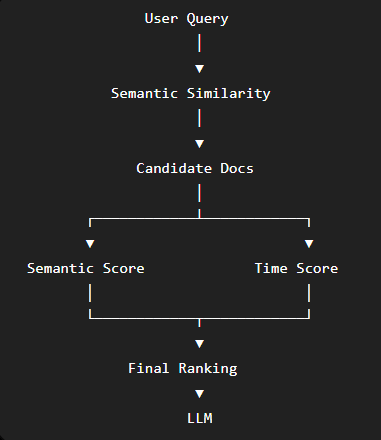




In [16]:
from sentence_transformers import SentenceTransformer
import numpy as np
from datetime import datetime

model = SentenceTransformer("all-MiniLM-L6-v2")

# ----------------------------------------
# Documents
# ----------------------------------------

documents = [
    {
        "text":"Alarm configuration procedure.",
        "date":"2023-01-15"
    },

    {
        "text":"New alarm configuration procedure.",
        "date":"2026-01-10"
    },

    {
        "text":"Circuit breaker manual.",
        "date":"2024-07-05"
    },

    {
        "text":"Transformer installation guide.",
        "date":"2025-12-20"
    }
]

# ----------------------------------------
# Query
# ----------------------------------------

query = "How do I configure alarms?"

# ----------------------------------------
# Semantic Similarity
# ----------------------------------------

texts = [d["text"] for d in documents]

embeddings = model.encode(texts)

query_embedding = model.encode(query)

semantic_scores = np.dot(
    embeddings,
    query_embedding
) / (
    np.linalg.norm(embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

# ----------------------------------------
# Time Score
# ----------------------------------------

today = datetime(2026, 7, 1)

time_scores = []

for doc in documents:

    age = (today - datetime.strptime(
        doc["date"],
        "%Y-%m-%d"
    )).days

    # Newer documents get higher scores
    score = 1 / (1 + age)

    time_scores.append(score)

# ----------------------------------------
# Normalize
# ----------------------------------------

semantic_scores = (
    semantic_scores - semantic_scores.min()
) / (
    semantic_scores.max() - semantic_scores.min()
)

time_scores = np.array(time_scores)

time_scores = (
    time_scores - time_scores.min()
) / (
    time_scores.max() - time_scores.min()
)

# ----------------------------------------
# Final Score
# ----------------------------------------

alpha = 0.7

final_scores = (
    alpha * semantic_scores
    +
    (1-alpha) * time_scores
)

# ----------------------------------------
# Ranking
# ----------------------------------------

ranking = sorted(
    zip(documents, final_scores),
    key=lambda x:x[1],
    reverse=True
)

print("\nTime Weighted Retrieval\n")

for doc, score in ranking:

    print(f"Score: {score:.3f}")

    print(doc["date"])

    print(doc["text"])

    print("-"*40)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9328.73it/s]



Time Weighted Retrieval

Score: 0.975
2026-01-10
New alarm configuration procedure.
----------------------------------------
Score: 0.700
2023-01-15
Alarm configuration procedure.
----------------------------------------
Score: 0.309
2025-12-20
Transformer installation guide.
----------------------------------------
Score: 0.035
2024-07-05
Circuit breaker manual.
----------------------------------------


## Metadata Filtering
Absolutely. Metadata Filtering is probably the easiest retrieval technique to understand, and it's one of the most important in production RAG systems.

The basic idea is:

Don't search the entire vector database. Search only the documents that satisfy certain metadata conditions.


                 User Query
                      │
                      ▼
             Metadata Filter
        chunk_type = image
                      │
                      ▼
        Filter Documents
                      │
                      ▼
          Similarity Search
                      │
                      ▼
               Final Result

In [19]:
from sentence_transformers import SentenceTransformer
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

# -------------------------------------
# Documents with metadata
# -------------------------------------

documents = [

    {
        "text":"Alarm acknowledgment process.",
        "chunk_type":"text",
        "page":12,
        "chapter":"Alarm"
    },

    {
        "text":"Alarm system screenshot.",
        "chunk_type":"image",
        "page":13,
        "chapter":"Alarm"
    },

    {
        "text":"OPC UA communication protocol.",
        "chunk_type":"text",
        "page":150,
        "chapter":"Communication"
    },

    {
        "text":"Transformer wiring diagram.",
        "chunk_type":"image",
        "page":200,
        "chapter":"Transformer"
    }

]

# -------------------------------------
# User Query
# -------------------------------------

query = "alarm"

# -------------------------------------
# Metadata Filter
# -------------------------------------

filtered_docs = []

for doc in documents:

    if doc["chunk_type"] == "image":
        filtered_docs.append(doc)

# -------------------------------------
# Similarity Search
# -------------------------------------

texts = [d["text"] for d in filtered_docs]

embeddings = model.encode(texts)

query_embedding = model.encode(query)

scores = np.dot(
    embeddings,
    query_embedding
) / (
    np.linalg.norm(embeddings, axis=1) *
    np.linalg.norm(query_embedding)
)

best = np.argmax(scores)

print(filtered_docs[best])

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 15519.95it/s]


{'text': 'Alarm system screenshot.', 'chunk_type': 'image', 'page': 13, 'chapter': 'Alarm'}


## Reranking 
Absolutely. Reranking is one of the most important techniques in modern RAG systems. In fact, many production RAG systems (OpenAI, Anthropic, Cohere, Azure AI Search, etc.) use a reranker because retrieval alone is not enough.

A retriever (BM25, Vector Search, Hybrid Search) is designed to retrieve candidate documents quickly.

                 User Query
                      │
                      ▼
             Similarity Search
                      │
             Top 20 Documents
                      │
                      ▼
           Cross Encoder Reranker
                      │
               Top 5 Documents
                      │
                      ▼
                     LLM

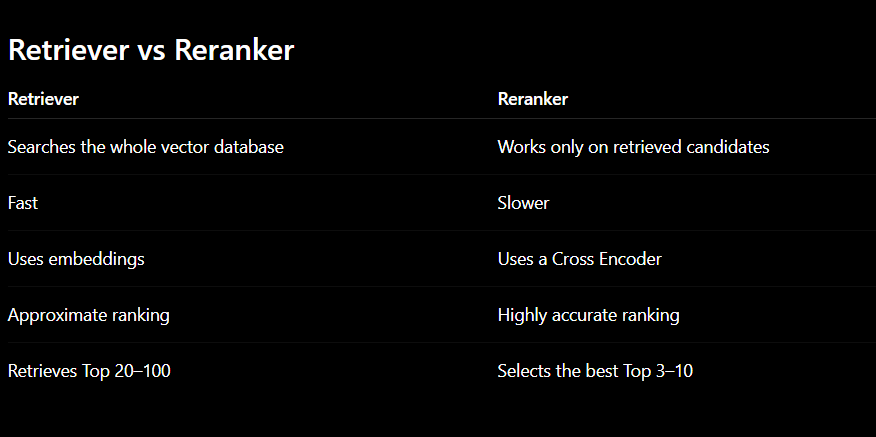

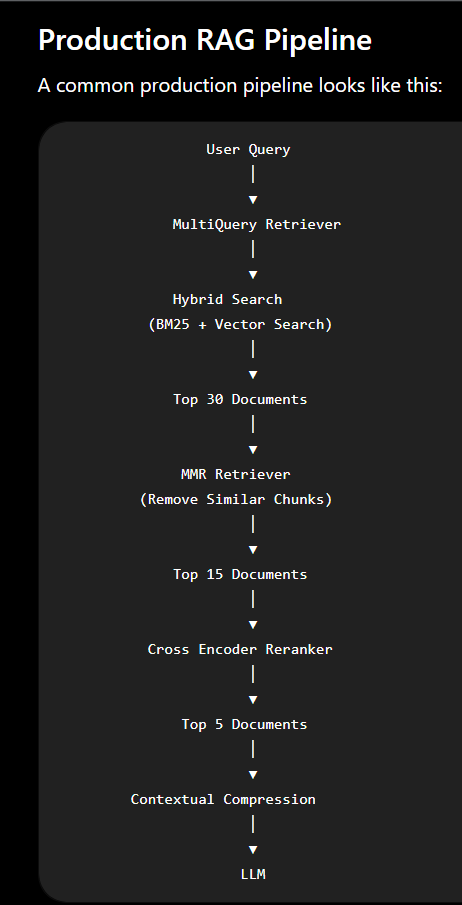

In [20]:
from sentence_transformers import CrossEncoder

# ------------------------------------
# Cross Encoder Model
# ------------------------------------

model = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L-6-v2"
)

# ------------------------------------
# Retrieved Documents
# ------------------------------------

documents = [

    "Circuit breaker protects electrical circuits.",

    "Circuit breaker maintenance procedure.",

    "How circuit breakers disconnect power during overload.",

    "Transformer installation guide.",

    "History of circuit breakers."
]

query = "How does a circuit breaker disconnect power?"

# ------------------------------------
# Query-Document Pairs
# ------------------------------------

pairs = [
    (query, doc)
    for doc in documents
]

scores = model.predict(pairs)

ranking = sorted(
    zip(documents, scores),
    key=lambda x:x[1],
    reverse=True
)

print("\nReranked Results\n")

for doc, score in ranking:

    print(score)

    print(doc)

    print("-"*40)

c:\RAG_POC\venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Rohit\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7608.62it/s]



Reranked Results

6.759202
How circuit breakers disconnect power during overload.
----------------------------------------
-0.87698185
Circuit breaker protects electrical circuits.
----------------------------------------
-3.8892808
Circuit breaker maintenance procedure.
----------------------------------------
-5.0198774
History of circuit breakers.
----------------------------------------
-11.072609
Transformer installation guide.
----------------------------------------


In [ ]:
from langchain.retrievers.document_compressors import CrossEncoderReranker

reranker = CrossEncoderReranker(
    model="cross-encoder/ms-marco-MiniLM-L-6-v2"
)

compression_retriever = ContextualCompressionRetriever(
    base_retriever=retriever,
    base_compressor=reranker
)

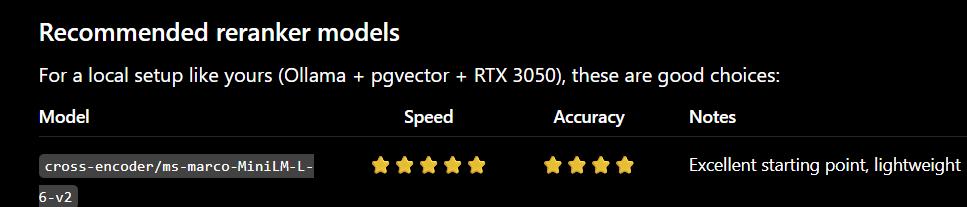